# Multiple Linear Regression Practical Implementation 

Here, we will be seeing the practical implementation of the Multiple Linear Regression 

In [15]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [16]:
df_index = pd.read_csv("economic_index.csv") 
df_index 

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [17]:
df_index.head()  

# here all the head values are getting printed here 

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [18]:
# Dropping the unnecessary columns goes on as: 

df_index.drop(columns = ["Unnamed: 0"], axis = 1, inplace = True) 

In [19]:
# After the removing of the unnecessary column, we get the final table as: 
df_index.head() 

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [20]:
# Now, checking the null values in the data goes on as: 

df_index.isnull().sum()  

## Here, as we can see that there are not much null values in the whole data as given below 

year                 0
month                0
interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

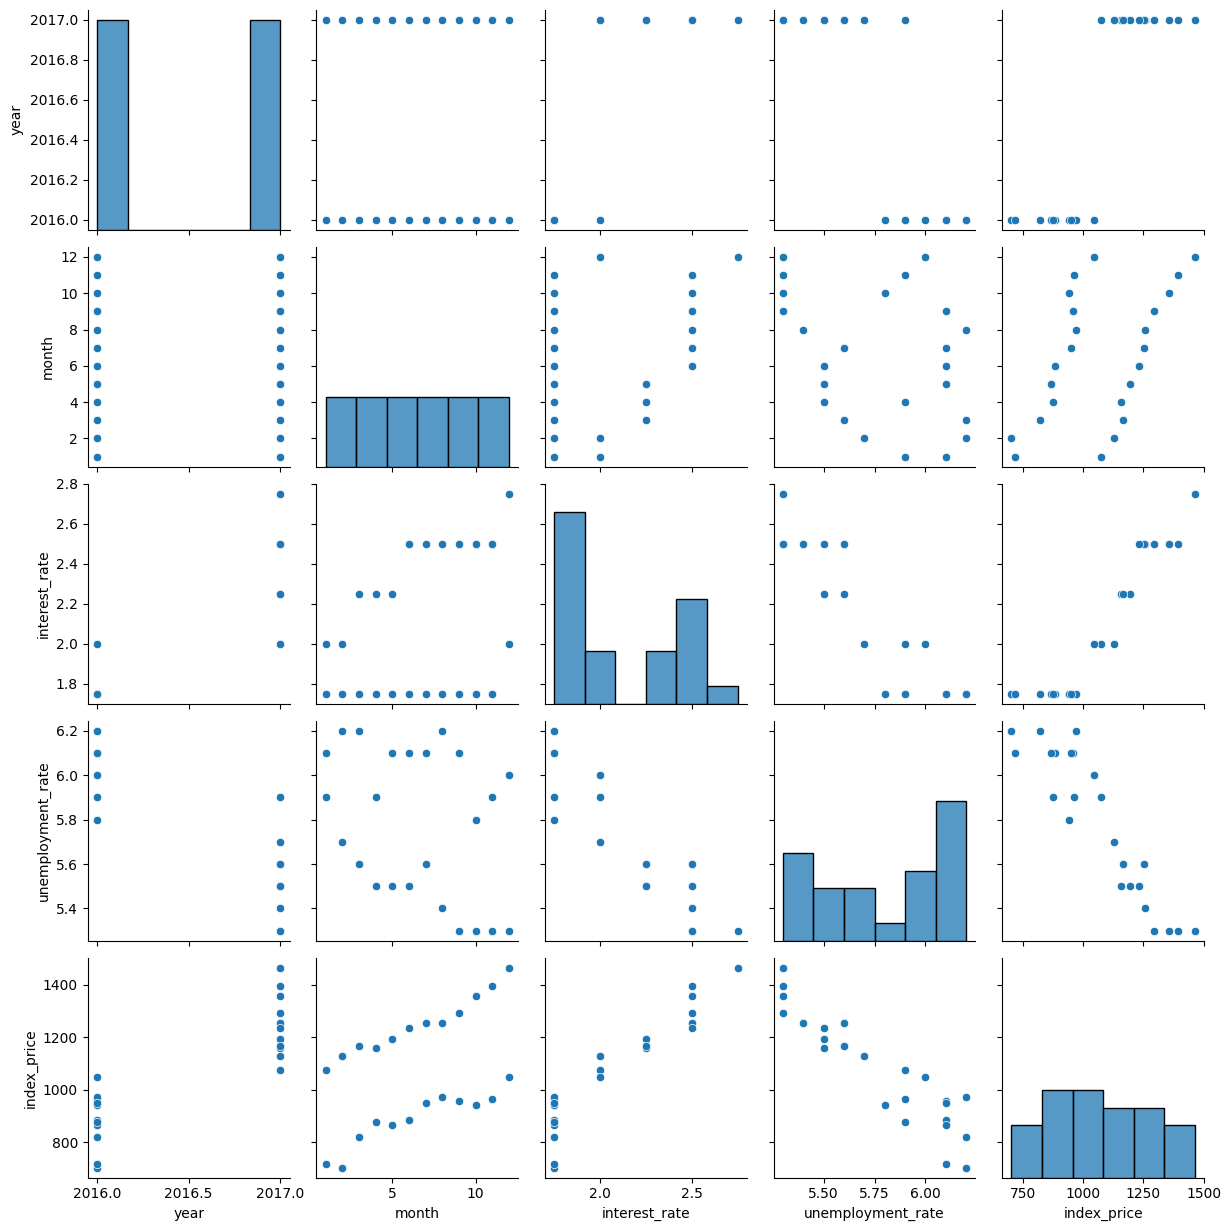

In [21]:
# Now, lets perform some visualixation as: 
import seaborn as sns 

sns.pairplot(df_index)  

# We have got the pairplot plotted below 

In [22]:
# Now, we try making the correlation of the plot as: 

df_index.corr()  

# Here, as we can see that we have got the correlation chart which basically tells the relation  
# - sig justifies the inverse relation here 

,year,month,interest_rate,unemployment_rate,index_price
year,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

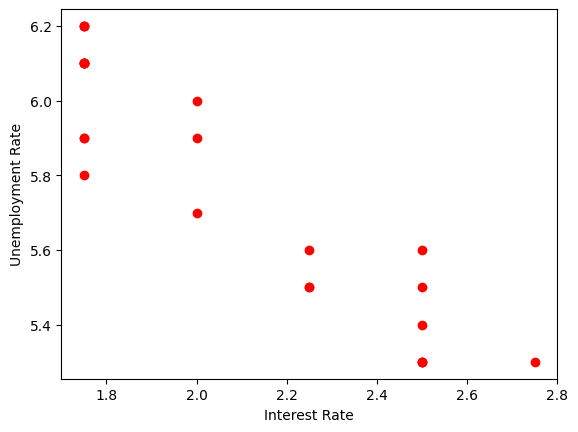

In [23]:
# Now, we will be visualizing the plot between the interet rate and the un employment rate wwhich is as: 

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color = 'r') 
plt.xlabel("Interest Rate") 
plt.ylabel("Unemployment Rate") 

# Here, we are getting the same graph as in the paiir plot which is plotted 

In [24]:
# Now, we will be seeing the dependent features which follows as: 
x = df_index.iloc[:, :-1] 
x  

# It basicaly means that to include all except the last column here 

,year,month,interest_rate,unemployment_rate
0,2017,12,2.75,5.3
1,2017,11,2.50,5.3
2,2017,10,2.50,5.3
3,2017,9,2.50,5.3
4,2017,8,2.50,5.4
5,2017,7,2.50,5.6
6,2017,6,2.50,5.5
7,2017,5,2.25,5.5
8,2017,4,2.25,5.5
9,2017,3,2.25,5.6


In [25]:
# Now, trying for the  dependent featuress as: 
y = df_index.iloc[:, -1] 
y 

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [26]:
# Now, applying the train, test split on the mdel for the proper appliication as: 

from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42) 


<Axes: xlabel='interest_rate', ylabel='index_price'>

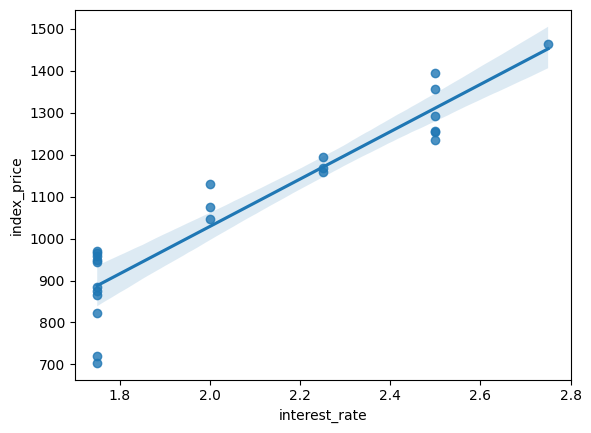

In [ ]:
# Now plottig of the reg plot for the proper plotting of the reg plot as: 
import seaborn as sns 
sns.regplot(x = df_index['interest_rate'], y = df_index['index_price'])  

# here as we can see that the reg plot ahs been plote

In the above regression plot we can clearly see that the line is best fitting and there are minimum errors in the whole plot 

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

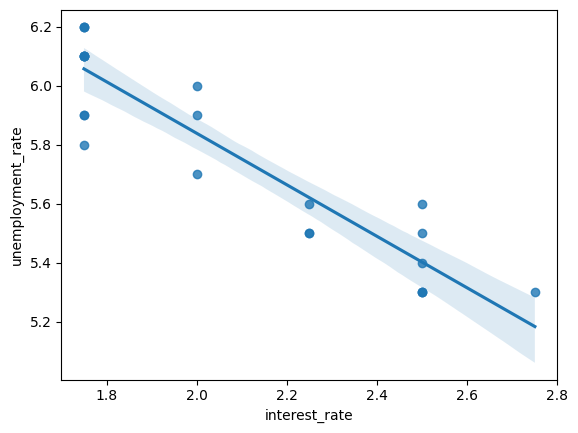

In [ ]:
sns.regplot(x = df_index['interest_rate'], y = df_index['unemployment_rate'])  

# here, we have got this proper regression plot which is being plotted here 

In [31]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 

x_train = scaler.fit_transform(x_train) 
x_test = scaler.transform(x_test) 

In [32]:
x_train 

array([[-0.89442719,  1.25692828, -0.90115511,  0.37908503],
       [ 1.11803399,  1.25692828,  1.31077107, -1.48187786],
       [-0.89442719, -1.12462004, -0.90115511,  1.30956648],
       [ 1.11803399,  0.06615412,  1.31077107, -0.55139641],
       [ 1.11803399,  0.95923474,  1.31077107, -1.48187786],
       [-0.89442719,  1.55462182, -0.16384638,  0.68924552],
       [-0.89442719,  0.6615412 , -0.90115511,  0.999406  ],
       [ 1.11803399,  0.6615412 ,  1.31077107, -1.48187786],
       [ 1.11803399,  0.36384766,  1.31077107, -1.17171738],
       [-0.89442719, -1.42231358, -0.90115511,  1.30956648],
       [-0.89442719,  0.06615412, -0.90115511,  0.999406  ],
       [-0.89442719, -0.8269265 , -0.90115511,  0.37908503],
       [-0.89442719, -1.72000712, -0.90115511,  0.999406  ],
       [ 1.11803399, -0.52923296,  0.57346234, -0.8615569 ],
       [ 1.11803399, -1.42231358, -0.16384638, -0.24123593],
       [-0.89442719,  0.95923474, -0.90115511,  0.06892455],
       [-0.89442719, -0.

In [33]:
x_test 

array([[ 1.11803399, -0.8269265 ,  0.57346234, -0.8615569 ],
       [-0.89442719,  0.36384766, -0.90115511,  1.30956648],
       [ 1.11803399,  1.55462182,  2.0480798 , -1.48187786],
       [-0.89442719, -0.23153942, -0.90115511,  0.999406  ],
       [ 1.11803399, -1.72000712, -0.16384638,  0.37908503],
       [ 1.11803399, -1.12462004,  0.57346234, -0.55139641]])

In [34]:
from sklearn.linear_model import LinearRegression 
regression = LinearRegression() 

In [ ]:
regression.fit(x_train, y_train)  

# here, the linear regression model has been implemented properly 


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Now, we will be seeing the cross validation score which basically means that a way to evaluate how well a model generalizes the unseen data rather than scoring well on the data, on which it was trained on. 

In [36]:
from sklearn.model_selection import cross_val_score  
validation_score = cross_val_score(regression, x_train, y_train, scoring = 'neg_mean_squared_error', cv = 3) 

# cv is basically used to distinguigh between the training dataset and also the validation dataset 

In [ ]:
validation_score  
# here, on priting the dataeet, we are getting the 3 mse values 

array([-1118.96622222, -2442.06672278, -1108.20691688])

In [38]:
# Now, taking a mean of the validation scores to get a single perfecct one as:  

np.mean(validation_score) 

np.float64(-1556.4132872905568)

In [ ]:
# Now, making the further prediction as: 

y_pred = regression.predict(x_test) 
y_pred  

# Here, we are getting the y_test 

array([1175.57032186,  929.78943375, 1393.85484386,  874.65503953,
       1097.34158614, 1150.01092165])

In [40]:
# Now, putting the performance metrics as: 

from sklearn.metrics import mean_absolute_error, mean_squared_error 

mse = mean_squared_error(y_test, y_pred) 
mae = mean_absolute_error(y_test, y_pred) 
rmse =  np.sqrt(mse) 

print(mse)
print(mae)
print(rmse)

1294.7221344877105
29.43361153262528
35.98224749077954


In [41]:
from sklearn.metrics import r2_score 
score = r2_score(y_test, y_pred) 

print(score) 

0.9615406221808906


In [42]:
# Now, displaying the adjusted r square is done as: 

print(1 - (1 - score)*len((y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)) 


0.7692437330853439


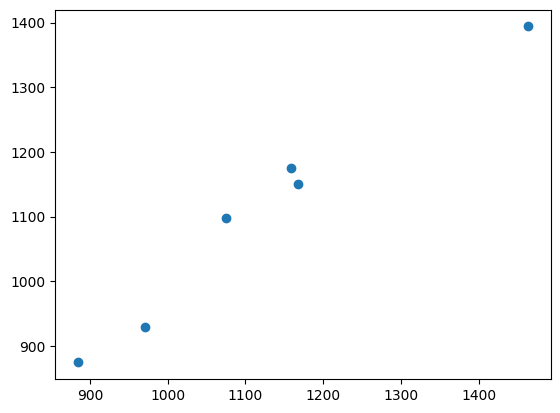

In [ ]:
plt.scatter(y_test, y_pred)  

# here the scatter plot has been plotted  

In [44]:
# Residuals are basically the errors between y_test and y_pred 

residuals = y_test - y_pred  
print(residuals) 

8    -16.570322
16    41.210566
0     70.145156
18     9.344960
11   -22.341586
9     16.989078
Name: index_price, dtype: float64


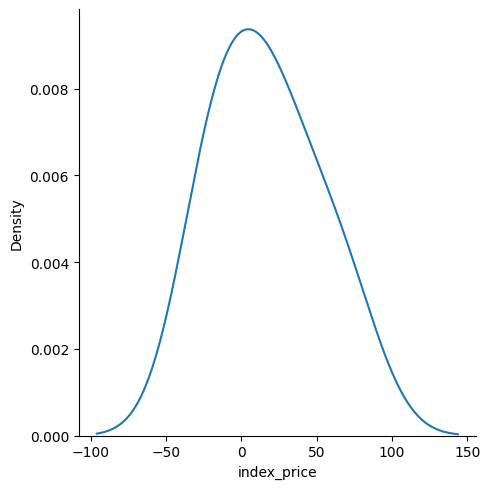

In [ ]:
# Creating a displot of the residual plot which oes on as: 

sns.displot(residuals,  kind = 'kde')  

# Here, if we are getting this type of kde plot, then it means that the plot is good and well defined 

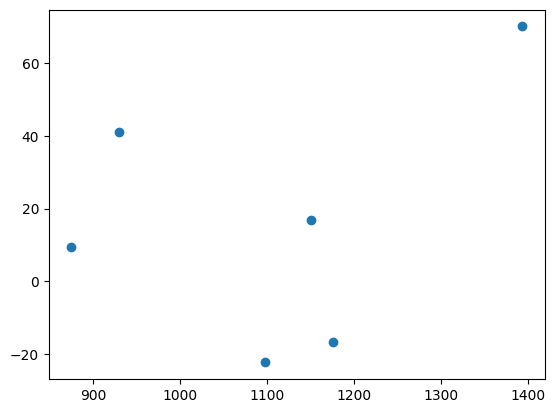

In [46]:
# Scatter plot wrt to y_pred and residuals, it goes on as: 

plt.scatter(y_pred, residuals) 